## Лабораторная работа #6. Решение ОДУ

Импорт библиотек и модулей

In [1]:
import numpy as np
from comp_math.ode.ode_registry import ODERegistry
from comp_math.linear_algebra.objects.matrix import Matrix
from comp_math.linear_algebra.objects.vector import Vector
import matplotlib.pyplot as plt

Условия задачи VIII.11.4

In [2]:
def f(tn: float, yn: Vector):
    x = yn[0]
    y = yn[1]
    z = yn[2]
    u = yn[3]
    f = Vector([0, 0, 0, 0])
    f[0] = z # x'
    f[1] = u # y'
    f[2] = - x / (x ** 2 + y ** 2) ** (3 / 2)
    f[3] = - y / (x ** 2 + y ** 2) ** (3 / 2)
    return f

y0 = [0.5, 0, 0, np.sqrt(3)]
t_span = [0, 20]
h = 0.05
dim = 4

In [3]:
methods = [
    (ODERegistry.create_solver("euler"), "Метод Эйлера"),
    (ODERegistry.create_solver("heun"),  "Метод Хойна"),
    (ODERegistry.create_solver("kutta"), "Метод Кутта 3"),
    (ODERegistry.create_solver("rk4"), "Метод RK4"),
]

Функции для построения графиков

In [4]:
def make_subplot(axes, t, y, ind, label):
    axes[ind].plot(t, list(map(lambda yn: yn[ind], y)), marker='o')
    axes[ind].set_title(label + "(t)")
    axes[ind].set_xlabel("time")
    axes[ind].set_ylabel(label)
    axes[ind].grid(True, alpha=0.3)
    # axes[ind].set_xticks(rotation=45)


def make_plot(t, y, title=""): 
    fig, axes = plt.subplots(4, 1, figsize=[8,12])

    make_subplot(axes, t, y, 0, "x")
    make_subplot(axes, t, y, 1, "y")
    make_subplot(axes, t, y, 2, "z")
    make_subplot(axes, t, y, 3, "u")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


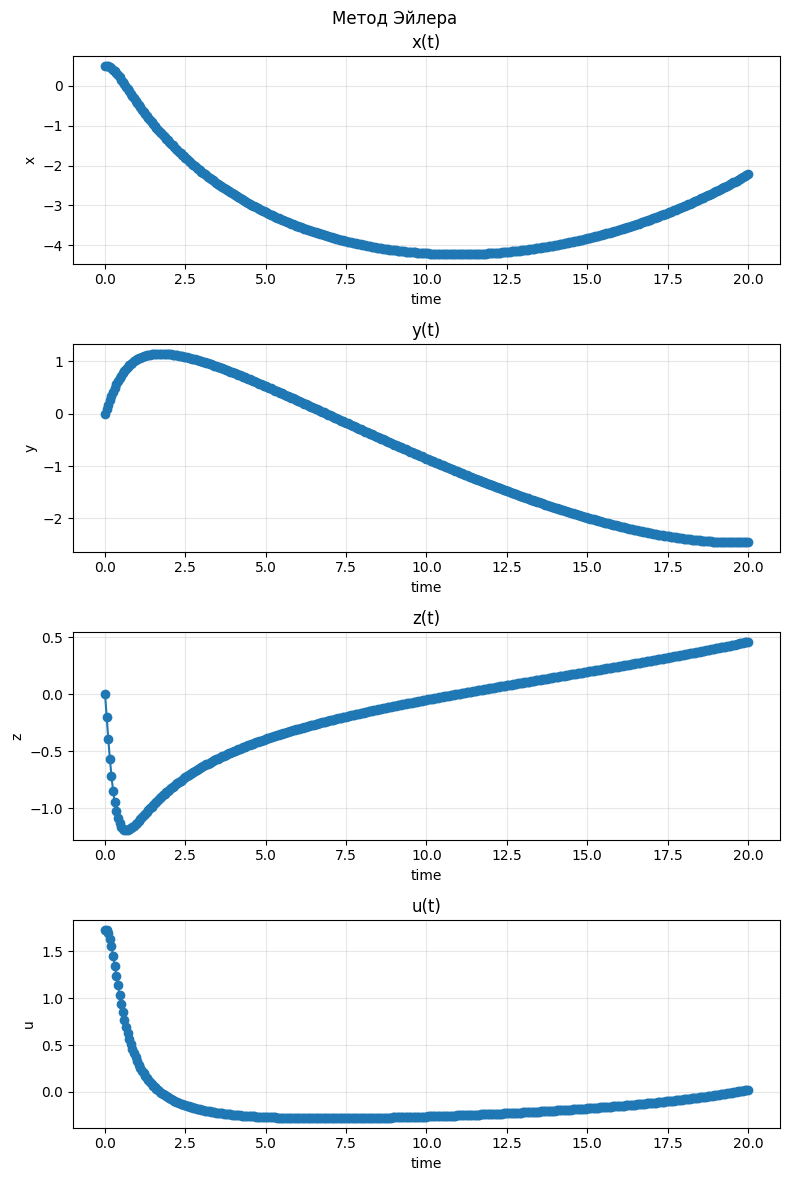

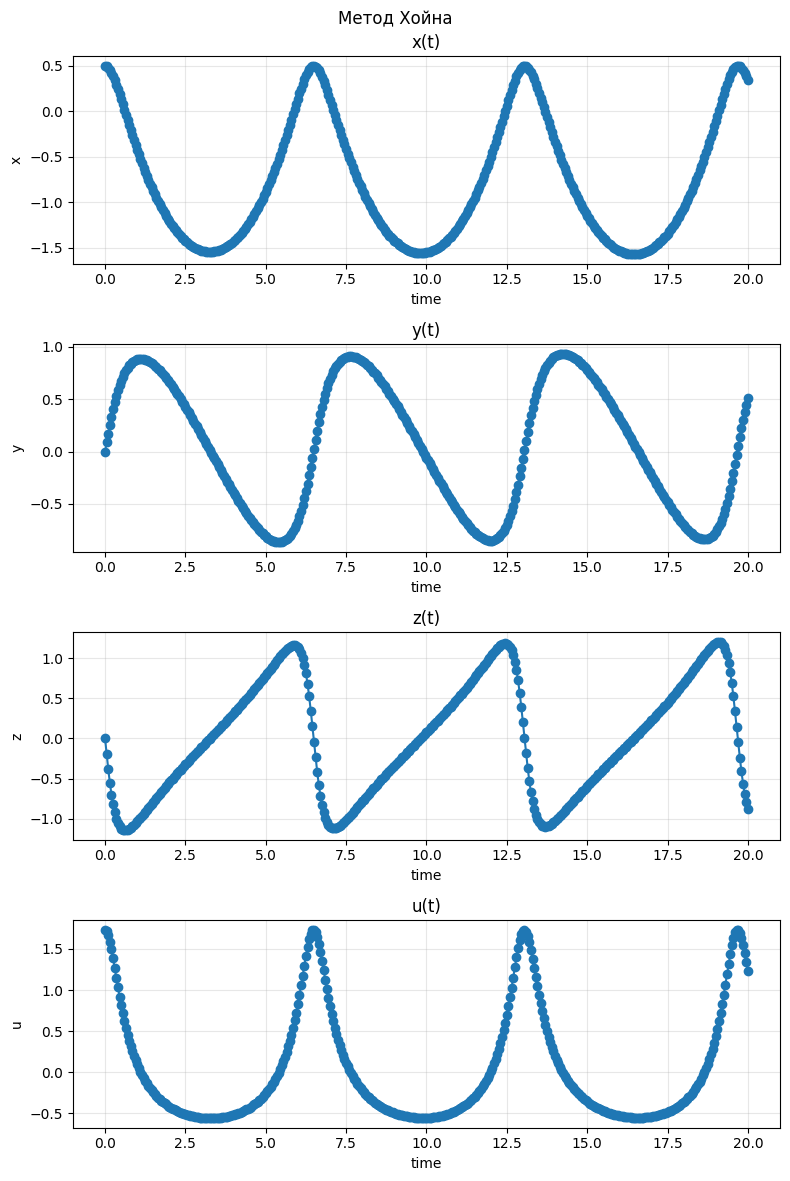

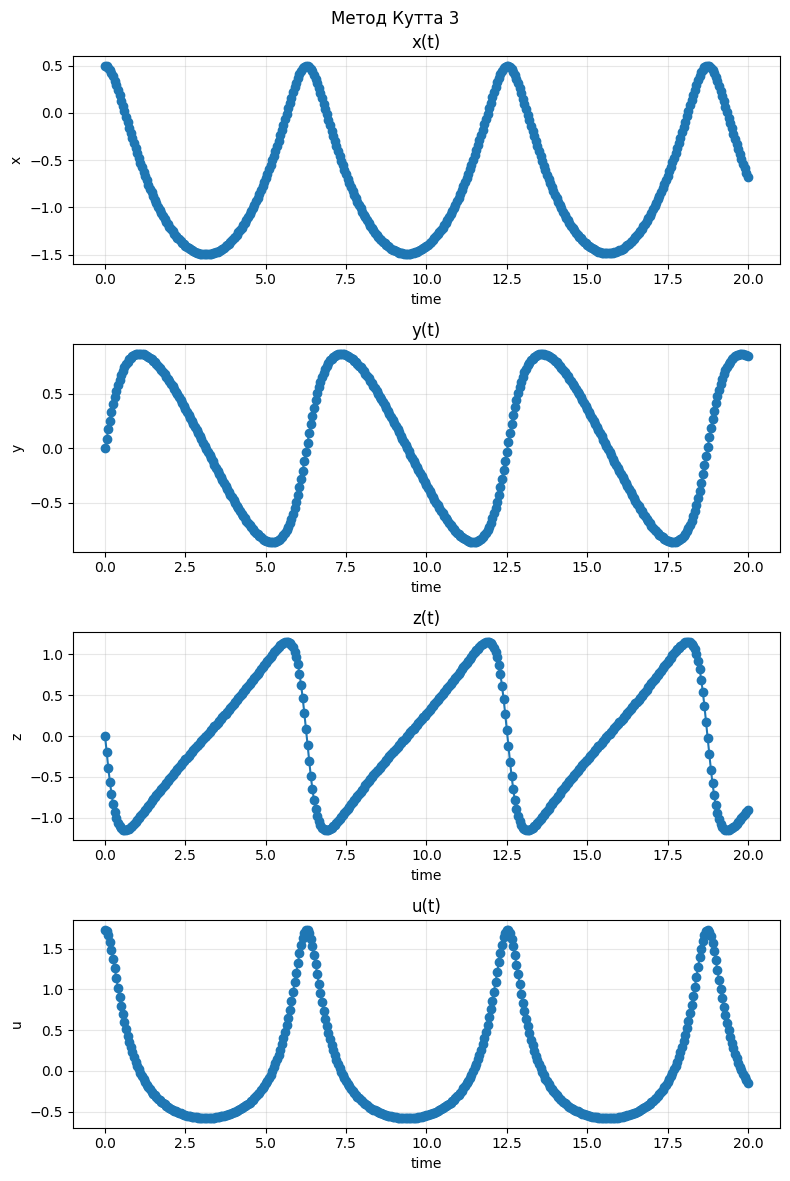

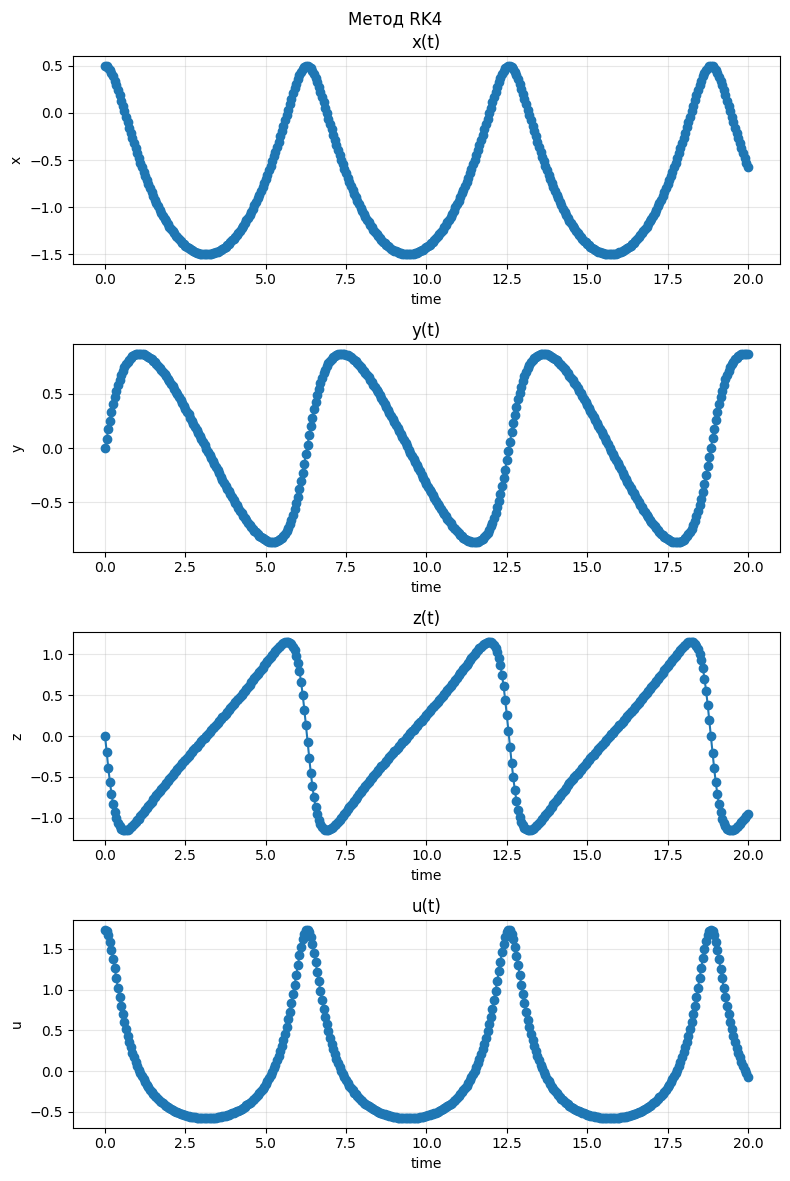

In [5]:
for method in methods:
    t, y = method[0].solve(f, dim, t_span, y0, h)
    make_plot(t, y, method[1])